## Preparing data for modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_predict, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv(r'C:\Users\grzeg\Portfolio\Credit-Risk-Prediction\south_german_credit\data\South German Credit.asc', delimiter = ' ')

In [3]:
df

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


In [4]:
df['credit_risk'] = df['credit_risk'].map({0:1, 1:0})

In [5]:
df['credit_risk'].value_counts()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [6]:
df['amount'] = np.log(df['amount'])

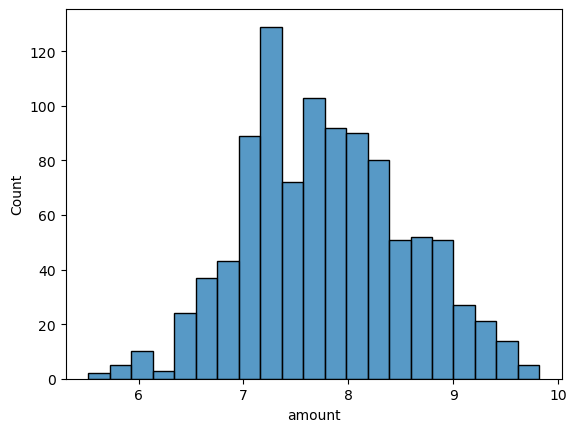

In [7]:
sns.histplot(data = df, x = 'amount');

In [8]:
num = ['duration', 'amount', 'age']
cat = df.drop(num + ['credit_risk'], axis = 1).columns

In [9]:
cat

Index(['status', 'credit_history', 'purpose', 'savings', 'employment_duration',
       'installment_rate', 'personal_status', 'other_debtors',
       'present_residence', 'property', 'other_installment_plans', 'housing',
       'number_credits', 'job', 'people_liable', 'telephone',
       'foreign_worker'],
      dtype='object')

In [10]:
X = df.drop('credit_risk', axis = 1)
y = df['credit_risk']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [12]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

## Base models + choosing best feature sets

In [26]:
algos = [LogisticRegression(random_state = 42), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [28]:
from sklearn.metrics import make_scorer, recall_score, precision_score, roc_auc_score, average_precision_score

In [30]:
scoring = {
    'roc_auc':'roc_auc',
    'avg_precision':'average_precision',
    "recall_1": make_scorer(recall_score, pos_label=1),
    "recall_0": make_scorer(recall_score, pos_label=0),
    "precision_1": make_scorer(precision_score, pos_label=1),
}

In [32]:
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

In [34]:
feature_sets = {
    "with_all": num + list(cat),
    "without_job": num + [col for col in cat if col != "job"],
    "without_credit_history": num +[col for col in cat if col != "credit_history"],
    "without_personal_status": num + [col for col in cat if col !="personal_status"],
    "without_job&credit_history": num + [col for col in cat if col != "job" and col != "credit_history"],
    "without_job&personal_status": num + [col for col in cat if col != "job" and col != "personal_status"],
    "without_credit_history&personal_staus": num + [col for col in cat if col != "credit_history" and col != "personal_status"],
    "without_job&credit_history&personal_status": num + [col for col in cat if col != "job" and col != "credit_history" and col != "personal_status"]
}

In [56]:
results = []
for c_names, columns in feature_sets.items():
    numeric = [col for col in columns if col in num]
    categorical = [col for col in columns if col in cat]
    transformer = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(drop = 'first'), categorical)])
    for algo, name in zip(algos, names):
        pipe = Pipeline([('transformer', transformer), ('clf',algo)])
        c_v = cross_validate(pipe, X_train[columns], y_train, scoring = scoring, cv = cv, return_train_score = True, n_jobs = -1)
        results.append({'feature_sets':c_names,
                        'model': name,
                        'roc_auc': c_v['test_roc_auc'].mean(),
                        'avg_precision': c_v['test_avg_precision'].mean(),
                        'recall_1': c_v['test_recall_1'].mean(),
                        'recall_0': c_v['test_recall_0'].mean(),
                        'precision_1': c_v['test_precision_1'].mean()})

In [54]:
pd.DataFrame(results).sort_values(['name', 'roc_auc', 'avg_precision'], ascending = [True, False, False])

,name,type,roc_auc,avg_precision,recall_1,recall_0,precision_1
32,Decision Tree,without_job&personal_status,0.619643,0.379535,0.483333,0.755952,0.459229
20,Decision Tree,without_personal_status,0.619444,0.378378,0.476389,0.762500,0.461810
38,Decision Tree,without_credit_history&personal_staus,0.618849,0.377362,0.484722,0.752976,0.460278
44,Decision Tree,without_job&credit_history&personal_status,0.617758,0.378570,0.465278,0.770238,0.468201
2,Decision Tree,with_all,0.616270,0.376865,0.469444,0.763095,0.459104
8,Decision Tree,without_job,0.610714,0.370686,0.483333,0.738095,0.443008
14,Decision Tree,without_credit_history,0.608333,0.369006,0.466667,0.750000,0.446028
26,Decision Tree,without_job&credit_history,0.602480,0.366231,0.455556,0.749405,0.441346
7,KNN,without_job,0.701277,0.454323,0.383333,0.838690,0.507620
1,KNN,with_all,0.692237,0.457559,0.372222,0.849405,0.515534


In [58]:
def overfitting(df:pd.DataFrame):
    return{"roc_auc_mean": df["train_roc_auc"].mean() - df["test_roc_auc"].mean(),
          'pr-auc_mean': df['train_avg_precision'].mean() - df['test_avg_precision'].mean() ,
          "recall_1_mean": df["train_recall_1"].mean() - df["test_recall_1"].mean(),
          "recall_0_mean": df["train_recall_0"].mean() - df["test_recall_0"].mean(),
          "precision_1_mean": df["train_precision_1"].mean() - df["test_precision_1"].mean()}

## Nested Cross Validation

In [27]:
from scipy.stats import loguniform, uniform, randint

In [29]:
pd_rl = {'clf__penalty': ['l1', 'l2', 'elasticnet'],
        'clf__C': loguniform(1e-3, 1e3),
         'clf__l1_ratio': uniform(0,1)
        }
pd_knn = {'clf__n_neighbors': randint(1, 51),
          "clf__weights": ["uniform", "distance"],
          "clf__p": randint(1, 2)
         }
pd_dt = {'clf__max_depth': randint(1,16),
         'clf__min_samples_split': randint(2,16),
         'clf__min_samples_leaf': randint(1,21),
         'clf__ccp_alpha':loguniform(1e-5, 1e-1),
         'clf__max_leaf_nodes': randint(2,16)
        }
pd_rf = {'clf__n_estimators': randint(50, 501),
         'clf__max_depth': randint(1,10),
         'clf__min_samples_leaf': randint(1,16),
         'clf__max_features': ['sqrt','log2']
        }
pd_xgb = {'clf__colsample_bytree': uniform(0, 1),
          'clf__subsample': uniform(0, 1),
          'clf__learning_rate': loguniform(1e-4, 1e0),
          'clf__max_depth': randint(1,10),
          'clf__n_estimators': randint(50, 501),
          'clf__reg_alpha': loguniform(1e-4, 1e1),
          'clf__reg_lambda': loguniform(1e-4, 1e2),
          'clf__gamma': loguniform(1e-8, 1e1)
         }
pd_svm = {'clf__kernel': ['rbf', 'poly', 'sigmoid'],
          'clf__C': loguniform(1e-3, 1e3),
          'clf__gamma': loguniform(1e-4, 1e0),
          'clf__degree': randint(2,6)
         }
param_distributions = [pd_rl, pd_knn, pd_dt, pd_rf, pd_xgb, pd_svm]

In [31]:
X = df.drop(['credit_risk', 'job'], axis = 1)
y = df['credit_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [33]:
from sklearn.metrics import make_scorer, recall_score, precision_score, roc_auc_score, average_precision_score

In [35]:
scoring = {
    'roc_auc':'roc_auc',
    'avg_precision':'average_precision',
    "recall_1": make_scorer(recall_score, pos_label=1),
    "recall_0": make_scorer(recall_score, pos_label=0),
    "precision_1": make_scorer(precision_score, pos_label=1),
}

In [67]:
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

In [69]:
from collections import Counter

In [71]:
counter = Counter(y_train)

In [73]:
scale_pos_weight = counter[0]/counter[1]

In [75]:
inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
outer_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 2)

In [77]:
n_iters = [50, 50, 50, 200, 300, 200]

In [104]:
def training(pipe, results):
    
    for model, param, n, name in zip(pipe, param_distributions, n_iters, results.keys()):
        for fold_id, (train, test) in enumerate(outer_cv.split(X_train, y_train)):
            X_tr, X_te = X_train.iloc[train], X_train.iloc[test]
            y_tr, y_te = y_train.iloc[train], y_train.iloc[test]
            r_s = RandomizedSearchCV(estimator = model, param_distributions = param, n_iter = n, scoring = scoring, n_jobs = -1, refit = 'roc_auc', cv = inner_cv, random_state = 42, return_train_score = True) 
            r_s.fit(X_tr, y_tr)
            best_model = r_s.best_estimator_
            best_params = r_s.best_params_
            y_pred = r_s.predict(X_te)
            p_te = r_s.predict_proba(X_te)[:,1]
            results[name].append({
            'fold': fold_id,
            'params': best_params,
            'roc_auc': roc_auc_score(y_te, p_te),
            'avg_precision': average_precision_score(y_te, p_te),
            'recall_1': recall_score(y_te, y_pred, pos_label=1),
            'precision_1': precision_score(y_te, y_pred, pos_label=1, zero_division=0),
            'recall_0': recall_score(y_te, y_pred, pos_label=0)})

In [106]:
numeric = ['age', 'amount', 'duration']
categorical = df.drop(numeric + ['credit_risk'] + ['job'], axis = 1).columns

In [108]:
transformer = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(drop = 'first'), categorical)])

### Class_weight = 'balanced' models

In [121]:
algos_cw = [LogisticRegression(random_state = 42, class_weight = 'balanced', solver = 'saga'), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42, class_weight = 'balanced'), 
         RandomForestClassifier(random_state =42, class_weight = 'balanced'), 
         XGBClassifier(random_state =42, scale_pos_weight = scale_pos_weight), 
         SVC(random_state = 42, probability=True, class_weight = 'balanced')]

In [123]:
pipes_cw = []
for algo in algos_cw:
    pipes_cw.append(Pipeline([('transformer', transformer), ('clf', algo)]))

In [125]:
results_cw.keys()

dict_keys(['LogisticRegression_cw', 'KNN_cw', 'Decision Tree_cw', 'Random Forest_cw', 'XGBoost_cw', 'SVM_cw'])

In [127]:
results_cw = {
    'Logistic Regression_cw':[],
    'KNN_cw':[], 
    'Decision Tree_cw':[], 
    'Random Forest_cw':[], 
    'XGBoost_cw':[], 
    'SVM_cw': []   
}

In [129]:
training(pipes_cw, results_cw)

C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_log

In [134]:
results_cw

{'Logistic Regression_cw': [{'fold': 0,
   'params': {'clf__C': 0.6812233896860297,
    'clf__l1_ratio': 0.1195942459383017,
    'clf__penalty': 'l2'},
   'roc_auc': 0.7414434523809524,
   'avg_precision': 0.5580847369118778,
   'recall_1': 0.7291666666666666,
   'precision_1': 0.5072463768115942,
   'recall_0': 0.6964285714285714},
  {'fold': 1,
   'params': {'clf__C': 1.3335385049873036,
    'clf__l1_ratio': 0.9611720243493491,
    'clf__penalty': 'l1'},
   'roc_auc': 0.7687872023809523,
   'avg_precision': 0.567434529410991,
   'recall_1': 0.6666666666666666,
   'precision_1': 0.5161290322580645,
   'recall_0': 0.7321428571428571},
  {'fold': 2,
   'params': {'clf__C': 0.6812233896860297,
    'clf__l1_ratio': 0.1195942459383017,
    'clf__penalty': 'l2'},
   'roc_auc': 0.8301711309523809,
   'avg_precision': 0.6942673948336574,
   'recall_1': 0.8125,
   'precision_1': 0.5492957746478874,
   'recall_0': 0.7142857142857143},
  {'fold': 3,
   'params': {'clf__C': 0.3905441275210791,
  

In [136]:
import joblib
joblib.dump(results_cw, 'C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results.joblib')

['C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results.joblib']

### Undersampling models

In [140]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state = 42)

In [142]:
algos_rus = [LogisticRegression(random_state = 42, solver = 'saga'), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [144]:
transformer = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(drop = 'first'), categorical)]) 

In [148]:
pipes_rus = []
for model in algos_rus:
    pipes_rus.append(Pipeline(steps = [('pre', transformer), ('rus', rus), ('clf', model)]))

In [152]:
results_rus = {
    'Logistic Regression_rus':[],
    'KNN_rus':[], 
    'Decision Tree_rus':[], 
    'Random Forest_rus':[], 
    'XGBoost_rus':[], 
    'SVM_rus': []   
}

In [154]:
training(pipes_rus, results_rus)

C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [158]:
import joblib
joblib.dump(results_rus, 'C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/rus_nested_cv_results.joblib')

['C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/rus_nested_cv_results.joblib']

### Oversampling models

In [166]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

In [168]:
algos_smote = [LogisticRegression(random_state = 42, solver = 'saga'), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [170]:
pipes_smote = []
for model in algos_smote:
    pipes_smote.append(Pipeline(steps = [('pre', transformer), ('smote', smote), ('clf', model)]))

In [176]:
results_smote = {
    'Logistic Regression_smote':[],
    'KNN_smote':[], 
    'Decision Tree_smote':[], 
    'Random Forest_smote':[], 
    'XGBoost_smote':[], 
    'SVM_smote': []   
}

In [180]:
training(pipes_smote, results_smote)

C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag

In [184]:
import joblib
joblib.dump(results_smote, 'C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/smote_nested_cv_results.joblib')

['C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/smote_nested_cv_results.joblib']

## Results summary

In [37]:
import joblib
results_cw = joblib.load('C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results.joblib')
results_rus = joblib.load('C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/rus_nested_cv_results.joblib')
results_smote = joblib.load('C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/smote_nested_cv_results.joblib')

In [169]:
metrics = ['roc_auc', 'avg_precision', 'recall_1', 'precision_1', 'recall_0']
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

In [231]:
summary_cw = {}
for name in names:
    mets = {}
    for metric in metrics:
        value = [] 
        for fold in range(5):
            value.append(results_cw[name][fold]['metrics'][metric])
        mets[metric] = value
    summary_cw[name] = mets

In [233]:
final_cw_summary = {}
for name in names:
    values = {}
    for metric in metrics:
        values[f'{metric}_mean'] = np.mean(summary_cw[name][metric])
        values[f'{metric}_std'] = np.std(summary_cw[name][metric])                         
    final_cw_summary[name] = values

In [235]:
df_cw = pd.DataFrame(final_cw_summary).T

In [237]:
df_cw

,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,recall_1_mean,recall_1_std,precision_1_mean,precision_1_std,recall_0_mean,recall_0_std
Logistic Regression,0.768006,0.034468,0.583066,0.065811,0.695833,0.048591,0.510135,0.033971,0.712500,0.032635
KNN,0.739732,0.035326,0.517374,0.025239,0.145833,0.029463,0.562704,0.097126,0.950000,0.016560
Decision Tree,0.686328,0.036871,0.432139,0.037869,0.741667,0.031180,0.434157,0.024194,0.583929,0.040955
Random Forest,0.767597,0.024329,0.579921,0.035425,0.633333,0.033850,0.504760,0.035393,0.730357,0.044248
XGBoost,0.765551,0.035318,0.569583,0.051075,0.675000,0.064010,0.493114,0.050541,0.700000,0.048445
SVM,0.779353,0.027433,0.603919,0.057245,0.712500,0.073834,0.525191,0.017280,0.723214,0.036158


In [240]:
from imblearn.under_sampling import RandomUnderSampler